In [66]:
%matplotlib widget
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm import tqdm
from numba import njit
import matplotlib.animation as animation
from matplotlib.widgets import Slider

In [103]:
J = 1
@njit
def Nsy_state(L,p):
        psi_i = np.ones((L,L), dtype = np.int64)
        return np.where(np.random.rand(L,L) < p, -1, psi_i)
@njit
def syndrome_calc(psi):
        syndr_arr = []
        for i in range(0, len_psi - 1):
                syndr_arr.append(psi[i]*psi[i+1])
        return syndr_arr

@njit
def s_ij(psi_m, psi_p):
        return psi_m*psi_p

@njit
def DecodeStep2D(i,j,psi,L):
        DE = 0
        #calculate syndromes with nns vertically
        if i + 1 < L:
                DE += s_ij(psi[i,j], psi[i+1,j])
        if i - 1 >= 0:
                DE += s_ij(psi[i,j], psi[i-1,j])
        #calculate syndromes with nns horizontally
        if j + 1 < L:
                DE += s_ij(psi[i,j], psi[i,j+1])
        if j - 1 >= 0:
                DE += s_ij (psi[i,j], psi[i,j-1])
        DE *= 2*J
        if DE < 0:
                psi[i,j] *= -1
        elif DE ==  0:
                if np.random.rand() < 0.5:
                        psi[i,j] *= -1
        return psi


@njit
def Decoding_sweep(psi):
        L = psi.shape[0] #length of square lattice
        for _ in range(L*L): 
                i = np.random.randint(0,L)
                j = np.random.randint(0,L)

                psi = DecodeStep2D(i,j,psi,L)
        return psi

### 2D Glauber dynamics simulation

In [79]:
#Now for snapshot simulation
L = 50
p_i = 0.5
psi = Nsy_state(L,p_i)

snapshots = []
times = []

max_steps = 3000

for t in tqdm(range(max_steps), desc = "Progression:"):
        psi = Decoding_sweep(psi)

        if t % 1  == 0:
                snapshots.append(psi.copy())
                times.append(t)

        if abs(np.sum(psi)) == L*L: #break loop if convergent to GS
                snapshots.append(psi.copy())
                times.append(t)
                break

Progression::  73%|███████▎  | 2187/3000 [00:02<00:00, 843.48it/s] 


Text(0.5, 0.98, '2D Glauber Dynamics (T = 0, p_i = 0.5)')

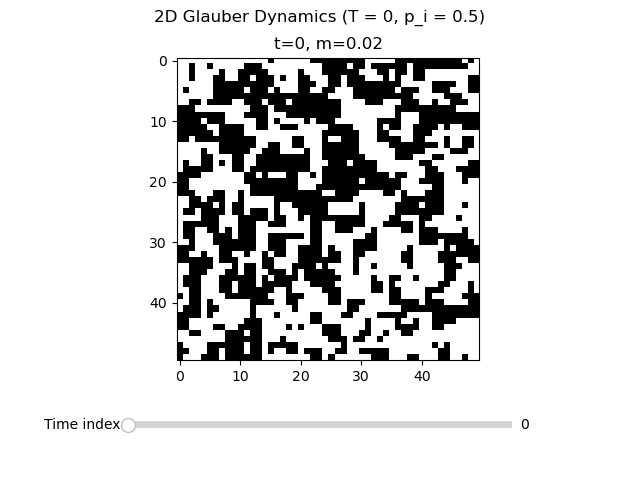

In [80]:
#Plotting, attempting an interactive/dynamic plot
fig, ax = plt.subplots()
    
plt.subplots_adjust(bottom = 0.25)
cmap = ListedColormap(["black","white"])
im = ax.imshow(snapshots[0], cmap=cmap, vmin=-1, vmax=1)
title = ax.set_title("")
def update_plot(idx):
    snap = snapshots[idx]
    im.set_data(snap)
    m = np.sum(snap) / (L * L)
    title.set_text(f"t={times[idx]}, m={m:.2f}")
    fig.canvas.draw_idle()

# Slider axis
ax_slider = plt.axes([0.2, 0.1, 0.6, 0.03])
slider = Slider(ax_slider, 'Time index', 0, len(snapshots)-1, valinit=0, valstep=1)

def on_slider(val):
    update_plot(int(slider.val))

def save_gif(snapshots, filename="glauber.gif", interval=200):
    fig, ax = plt.subplots()
    cmap = ListedColormap(["black", "white"])

    im = ax.imshow(snapshots[0], cmap=cmap, vmin=-1, vmax=1)
    ax.axis("off")

    def update(frame):
        im.set_array(snapshots[frame])
        return [im]

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(snapshots),
        interval=interval,
        blit=True
    )

    ani.save(filename, writer='pillow')
    plt.close(fig)

    print(f"Saved GIF as {filename}")

slider.on_changed(on_slider)

# initialize display
update_plot(0)

plt.suptitle(f"2D Glauber Dynamics (T = 0, p_i = {p_i})")

In [65]:
#chose to save or not:
save_gif(snapshots, "Metastable2.gif")

Saved GIF as Metastable2.gif


### Testing for threshold

In [130]:
@njit
def FullEvolutionM(L,p):
    max_steps = 7000
    psi = Nsy_state(L,p)
    for t in range(max_steps):
        psi = Decoding_sweep(psi)
        if np.abs(np.sum(psi)) == L*L:
            break
    m = np.sum(psi)/(L*L)
    return m #returns average magnetization of final state

In [131]:
L_arr = [5,10,30]
p_arr = np.linspace(0.05, 0.7, 10)
trials = 200 # for sampling mean failure
results = {L: [] for L in L_arr}

In [132]:
for L_i in L_arr:
    for p_i in p_arr:
        fails = 0 
        for _ in tqdm(range(trials), desc=f"L={L_i}, p={p_i:.2f}"):
            m_final = FullEvolutionM(L_i,p_i)
            if m_final < 0:
                fails += 1
        p_f = fails/trials
        results[L_i].append(p_f)

L=30, p=0.70: 100%|██████████| 200/200 [00:00<00:00, 509.99it/s]


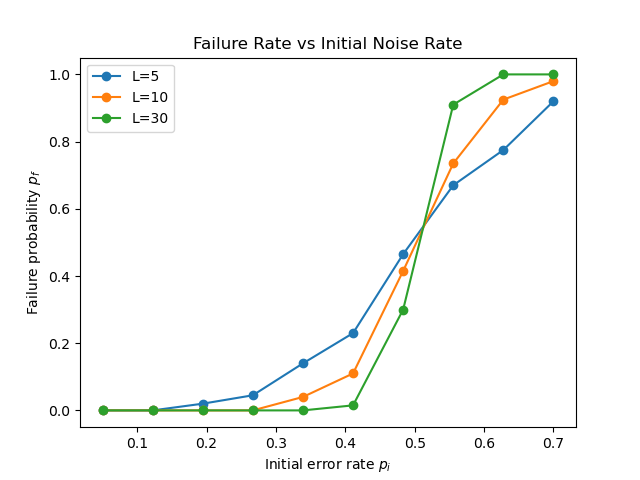

In [133]:
plt.figure()
for L in L_arr:
    plt.plot(p_arr, results[L], marker = 'o', label = f"L={L}")
plt.xlabel("Initial error rate $p_i$")
plt.ylabel("Failure probability $p_f$")
plt.title("Failure Rate vs Initial Noise Rate")
plt.legend()
plt.show()